# Multilayer Perceptrons

## Problem of bigrams
- The original design
    - The model only considers 1 previous token to determine next token -> 27 rows in matrix
- Exapnsion
    - Take n previous tokens to determine next token -> %27^n% rows in matrix
- Problem
    - The size of matrix will explode, which is not practical

## MLP Definition
A feedforward network with following traits
- fully connected
- At lest 3 layers
    - input
    - hiddne
    - output
- nonlinearity
    - Use nonlinear activation funciton: RELU, tanh or sigmoid
- Training
    - basckward propagation
 
- Side note
    - The fully connected layer at the end of Alexnet is a MLP 

## Refs
- [makmore github](https://github.com/karpathy/makemore?tab=readme-ov-file)
- [lecture jupyter](https://github.com/karpathy/nn-zero-to-hero/blob/master/lectures/makemore/makemore_part2_mlp.ipynb)

## MLP Paper Skim Through
- Takes 17,000 words and exmbeds them into 30-dim space.
- Through backward propagation, words have similar meaning will point to same point/area in the sapce

### Loss
- Maximize the likelihood = Maximize the log likelihood = Minize the negative log likelihood = Minize the Loss

### Why it works
- Good generalization
- For eaxmple
    - Train data has this: `The cat is walking in the bedroom`
    - The model can create: `A dog is strolling in a room`.
    - Reasons
        - The embedded of dog is similar to cat
        - The embedded of romm is similar to bedroom

### Neural Network Architecture
- First layer (Embeddings)
    - Look-up table (matrix C) has shape (17,000, 30)
        - Embed vocabthrough matrix C 
    - 3 neruon groups, each group has 30 neurons
    - 90 neurons in total
- Second layer
    - Number of neurons is a hyperparam
    -  tanh offers non-linearity
- Last layer
    - 17,000 neurons (17,000 vocabs choice)
    - softmax generates probability distribution

<img src="./assets/mlp-architecture.png" style="max-width: 600px">

- Params
    - Weights and biases from last and second layers + matrix of first layer.
    - Ignore the dash line for current implementation


## Our Architecture
- First Layer (embeddings)
    - Look-up Table C shape
        - C 
        - (27, 2)
    - Input 3 chars(converted to integer)
         - X 
         - entries are integer in range 0 - 26 
         - (m, 3) 
    - emb
        - emb = C[X]
        - shape: (m, 3, 2)
    - output
        - Current shape we have: 3 neurons, each neuron has 2 dimensional embeddings
        - Goal: we want shape:(m, 6)
        - Task
            - Transform 3 neurons to 6 neurons.
                - Convert 3 2-dimensional (m, 3, 2) embeddings to (m, 6) 
- Second Layer
     - 100 neurons (hypreparams)
     - W shape: (6, 100)
     - b shape: (,100)
- Third Layer
    - input_dim: 100
    - output_dim (number of neurons / number of unique chars): 27
    - w shape: (100, 27)
    - b shape: (,27)

## Build Context
- contexnt contains the nubmer of previous chars that model will consider to predict next char. The papar use 3

In [366]:
words = open('./assets/names.txt', 'r').read().splitlines()
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

In [18]:
N = torch.zeros(27, 27, dtype = torch.int32)

w_list = sorted(list(set(''.join([w for w in words]))))
itoc = {i + 1:c for i, c in enumerate(w_list)}
itoc[0] = '.'
ctoi = {value: key for key, value in itoc.items()}

In [312]:
# The context length
block_size = 3
# All available examples
X = []
# label
Y = []
# context
for w in words:
    context = [0] * block_size
    w = w + '.'
    # print('word:', w)
    for char in w:
        ix = ctoi[char]
        X.append(context)
        Y.append(ix)
        # Context and its next char
        # print(f"{"".join([itoc[integer] for integer in context])}, -----> {char}")
        context = context[1:] + [ix]
    # print("\n")
X = torch.tensor(X)
Y = torch.tensor(Y)

In [313]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

## Data Splitting
After we implement the gradient descent and train the model with all data. Through the following code, we can see that the loss is lower than the bigram. But actually, as long as we can have larger and larger params, the loss is goning to be low. But we will have overfitting problem. So we need to split our data into 3 parts

```py
# Total number of parameters 
sum([p.numel() for p in params])

# check total loss not just batch loss
emb = C[X]
z = emb.view(-1, 6) @ W1 + b1
h = torch.tanh(z)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss
```

- training split
    - 80%
    - optimize params
- dev/validatin split
    - 10%
    - Try all hyperparameters and find the optimial one
        - size of hidden layer
        - size of embedding
- test split
    - 10%
    - evalulate the performance of model at the end
    - Only evaluate with test split for few times, otherwise we will cause overfitting problem
  

In [326]:
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        w = w + '.'
        # print('word:', w)
        for char in w:
            ix = ctoi[char]
            X.append(context)
            Y.append(ix)
            # Context and its next char
            # print(f"{"".join([itoc[integer] for integer in context])}, -----> {char}")
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y
    
import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

## Disect Layers

In [245]:
g = torch.Generator().manual_seed(2147483647)

### First Layer Embeddings
- create a 2D dimensional space for the embedding purpose
- The shape of embedding matrix is (27, 2)
    - 27 chars
    - 2 dimensional vector for each char

In [246]:
# Return float type data
C = torch.randn((27, 2), generator = g)
# We can get entries with multiple dimension indexing.
emb = C[X]
emb.shape, emb.dtype

(torch.Size([32, 3, 2]), torch.float32)

### Convert 3 2-dimensional (m, 3, 2) embeddings 

In [335]:
# emb.storage()
'''
The storage show us the data actually stored by pytorch.
The torch.cat will create new storage. The torch.view only manipulate the representation of original storage.
The torch.view is the most efficient solution here

check the article for more info
https://blog.ezyang.com/2019/05/pytorch-internals/
'''

# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape
# torch.cat(torch.unbind(emb, 1), 1).shape
"""
len(torch.unbind(emb, 1))
torch.unbind(emb, 1)[0].shape
"""

# same as emb.view((emb.shape[0], 6)).shape, but the (-1, 6) is more elegant
# -1 means telling pytorch to infer the dimension by itself
converted_emb = emb.view((-1, 6))
converted_emb.shape

torch.Size([22860, 6])

### Second Layer 

In [271]:
W1 = torch.randn((6, 100), generator = g)
b1 = torch.randn(100, generator = g)

In [272]:
z = converted_emb @ W1 + b1
z.shape

torch.Size([32, 100])

In [273]:
h = torch.tanh(z)
h.shape

torch.Size([32, 100])

### Third Layer 


#### Manual Calculation

In [274]:
W2 = torch.randn((100, 27), generator = g)
b2 = torch.randn(27, generator = g)
logits = h @ W2 + b2
numerators = logits.exp()
prob = numerators / numerators.sum(1, keepdims=True)
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(17.6045, grad_fn=<NegBackward0>)

#### Cross Entropy

#### Why manual calculation can be problematic
- If we manually compute softmax and log-loss step by step, each intermediate tensor (like `exp(logits)`, probabilities, and `log(probs)`) needs to be stored in memory.
- `torch.nn.functional.cross_entropy()` is implemented in an optimized kernel that **fuses multiple operations together**, so it can reduce the number of intermediate tensors that must be saved.  
  ✅ This often saves memory and can also be faster.  
  *(This part was confusing for me at first, so I want to understand the fused-kernel idea more clearly.)*

#### Why `cross_entropy` is numerically stable
- A direct softmax computation can overflow because of the exponential function:

```py
logits = torch.tensor([4, 7, 2, 100])
logits.exp()  # exp(100) becomes extremely large and may overflow
````

* To avoid this, PyTorch uses a stability trick: it subtracts the maximum logit before applying `exp`:

$$
\text{softmax}(x) = \frac{e^{x - \max(x)}}{\sum_j e^{x_j - \max(x)}}
$$

* This prevents values like `exp(100)` from exploding, and avoids `inf` / `nan` issues during training.


If you want, I can also explain the “kernel fusion” part with a concrete example of what tensors would be created in the manual version vs `F.cross_entropy()` ✅

#### Why `cross_entropy` is more efficient for backward propagation

Another reason to use cross_entropy is that backward propagation is more efficient. Instead of backpropagating through exp(), division, and sum() step by step, PyTorch can use a fused implementation and the known analytic gradient formula for softmax + cross entropy.


In [275]:
loss = F.cross_entropy(logits, Y)
loss

tensor(17.6045, grad_fn=<NllLossBackward0>)

## Assemble Layers
- params preparation
- mini-batch
- froward
- backward
- loss
- graadient descent

In [367]:
g = torch.Generator().manual_seed(2147483647)

# number of neurons at tanh layer
n_tanh_layer = 200
context_len = 3
embededings_dim = 10
input_len = context_len * embededings_dim

# The look-up table
C = torch.randn((27, embededings_dim), generator = g)
W1 = torch.randn((input_len, n_tanh_layer), generator = g)
b1 = torch.randn(n_tanh_layer, generator = g)
W2 = torch.randn((n_tanh_layer, 27), generator = g)
b2 = torch.randn(27, generator = g)

params = [C, W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

In [344]:
## Number of Params
sum([p.numel() for p in params])

11897

In [336]:
for _ in range(10):
    # Forward Propagation
    emb = C[X]
    z = emb.view(-1, input_len) @ W1 + b1
    h = torch.tanh(z)
    logits = h @ W2 + b2
    
    # loss
    loss = F.cross_entropy(logits, Y)

    # backward
    for p in params:
        p.grad = None
    loss.backward()

    for p in params:
        p.data += -0.1 * p.grad
    print('loss: ', loss.item())

loss:  2.233289957046509
loss:  2.2297918796539307
loss:  2.227895975112915
loss:  2.2267491817474365
loss:  2.2259960174560547
loss:  2.225468635559082
loss:  2.225080728530884
loss:  2.2247841358184814
loss:  2.2245497703552246
loss:  2.2243590354919434


In [278]:
# Temporary check
print(logits.max(1))
print(Y)

torch.return_types.max(
values=tensor([ 3.2200,  4.2353,  4.3256, 10.0478, 10.9839,  3.2200,  7.6428,  6.6134,
        10.1744,  8.1834,  8.6831, 12.9649,  3.2200,  7.2405, 14.0030, 10.3830,
         3.2200,  6.9068,  6.5288,  9.9161,  8.7064,  6.4425,  5.7086,  9.1385,
        10.4474,  3.2200,  6.7765, 10.6660, 13.7952, 13.4320, 11.2552,  6.3556],
       grad_fn=<MaxBackward0>),
indices=tensor([ 9,  9,  6,  0,  0,  9,  1,  1,  1,  1, 25,  0,  9, 22,  1, 16,  9,  7,
         1, 19,  0, 16, 12,  1,  0,  9,  1, 16, 23,  9,  1,  1]))
tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])


## Enhancement and Tuning
### Minibatch
- Why
    - Faster gradient descent
- What
    - batch_size = 32

### Find optiaml learning-rate
- We roughly play around learning-rate to see if loss decrease consistently. Try [100, 0.00001] each step with to 10, to see if we get desired result. We can see that the range between 1 and 0.001 do make loss decrease consistently.

In [327]:
# learning rate exponent
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

Try to find the optimal learning rate, in the graph we can see that 0.1 is a pretty good learning rate

In [368]:
# 01 learning-rate finding elements
# lri = []
lossi = []
stepi = []
total_steps = 200000

for step in range(200000):
    # construct mini-batch index
    # Without Data Splitting
    # bix = torch.randint(0, X.shape[0], size=(32,))
    bix = torch.randint(0, Xtr.shape[0], size=(32,))
    
    
    # Forward Propagation
    emb = C[Xtr[bix]]
    z = emb.view(-1, input_len) @ W1 + b1
    h = torch.tanh(z)
    logits = h @ W2 + b2
    
    # loss
    loss = F.cross_entropy(logits, Ytr[bix])

    # backward
    for p in params:
        p.grad = None
    loss.backward()

    # 01 learning-rate finding elements
    # Through the graph we know that the 0.1 is a descent learning rate to start with
    # lr = lrs[step]
    # Now we know the 0.1 is descent
    # lr = 0.1
    # 02 Implement learning-rate decay
    lr = 0.1 if step < 100000 else 0.01
    for p in params:
        p.data += -lr * p.grad
    
    # 01 learning-rate finding elements    
    # lri.append(lre[step])
    stepi.append(step)
    lossi.append(loss.log10().item())

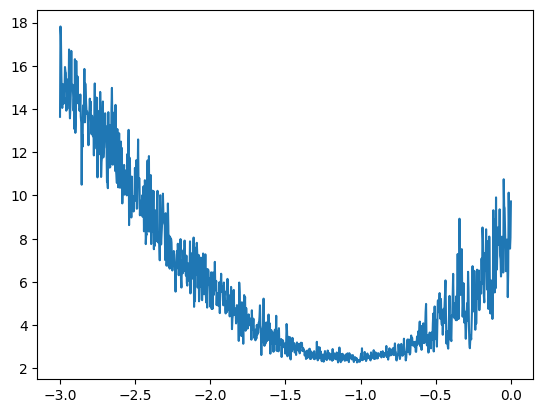

In [317]:
# 01 learning-rate finding elements 
plt.plot(lri, lossi)

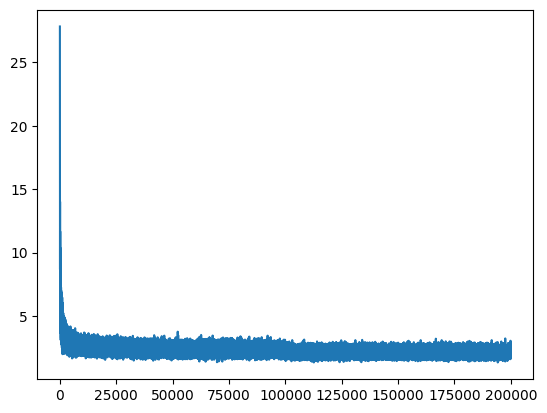

In [359]:
# with loss.item()
plt.plot(stepi, lossi)

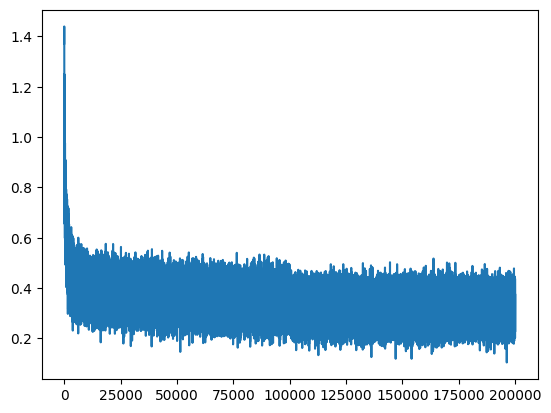

In [369]:
## lossi.append(loss.log10().item())
'''
log10() squashes the y axis
'''
plt.plot(stepi, lossi)

In [379]:
# check total loss not just batch loss
def compute_loss(X, Y):
    emb = C[X]
    z = emb.view(-1, input_len) @ W1 + b1
    h = torch.tanh(z)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    return loss.item()


x = np.arange(0, total_steps, 1)
train_loss = compute_loss(Xtr, Ytr)
dev_loss = compute_loss(Xdev, Ydev)
test_loss = compute_loss(Xte, Yte)
print('train loss: ', train_loss)
print('dev loss: ', dev_loss)
print('test loss: ', test_loss)

train loss:  2.1184747219085693
dev loss:  2.1548922061920166
test loss:  2.167275905609131


## Tuning
- Karpathy increase number of neurons at tanh layer, and train model mupltiple times. Although the loss of tring and dev set are both decreasing, the train loss and dev loss are high-ish and close. So he thinks it is undergitting so we should work on exapnding the size of embeddings.

- tanh layer
    - Increase the number of neurons from 100 to 200
- embedding
    - From 2-dimension to 10-dimension
 

- In later iterations, we want to see the gap between train_loss and dev_loss widen, so that we can know that the train_loss is overfitting and we have passed the optimal point.

- Bigram loss is around 2.4, so we can see that the test_loss of MLP 2.16 is clearly better.

## Prediction
|

In [387]:
g = torch.Generator().manual_seed(2147483647 + 10)


for i in range(20):
    out = []
    context = [0] * context_len # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] 
        z = emb.view(-1, input_len) @ W1 + b1
        h = torch.tanh(z)
        logits = h @ W2 + b2
        # Softmax
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples = 1, replacement = True, generator = g).item()
        context = context[1:] + [ix]
        out.append(itoc[ix])
        if ix == 0:
            break
    print(''.join(out))

carmah.
amoriq.
khy.
mish.
tavy.
skarsha.
jazhitn.
den.
art.
kaeli.
nellara.
chaiiv.
kaleigh.
ham.
jorn.
quintis.
lilea.
jamii.
wanelo.
dearynix.
